In [1]:
import fastf1
import pandas as pd
import numpy as np

# use the data stored locally
fastf1.Cache.enable_cache('../data/raw')

# load the race - bahrain
session = fastf1.get_session(2025, 4, 'R')
session.load()

laps = session.laps
clean_laps = laps.copy()

# drop incomplete/inaccurate laps - safety car laps, pit laps
clean_laps = clean_laps[clean_laps['IsAccurate'] == True]
clean_laps = clean_laps[clean_laps['PitInTime'].isnull() & clean_laps['PitOutTime'].isnull()]
clean_laps = clean_laps[~clean_laps['TrackStatus'].str.contains('4|6', na=False)]

# create Stint_ID - Cross-Validation Grouping Key
# a 'STINT' is a continuous run on one set of tires
# combine the Driver's 3-letter code with their integer Stint number
clean_laps['Stint_ID'] = clean_laps['Driver'] + "_Stint_" + clean_laps['Stint'].astype(int).astype(str)

# define the target variable
clean_laps['Target_Compound'] = clean_laps['Compound']



# convert LapTime from ns to s
clean_laps['LapTime_Sec'] = clean_laps['LapTime'].dt.total_seconds()

# calc PACE BASELINE: fastest lap time recorded on THAT SPECIFIC LapNumber across all drivers
field_best_per_lap = clean_laps.groupby('LapNumber')['LapTime_Sec'].min().reset_index()
field_best_per_lap.rename(columns={'LapTime_Sec': 'Field_Best_Lap_Sec'}, inplace=True)

# merge baseline back into clean_laps dataframe
clean_laps = clean_laps.merge(field_best_per_lap, on='LapNumber', how='left')

# calc DELTA: how much slower was this driver compared to the fastest car on this exact lap?
clean_laps['Delta_to_Field_Best'] = clean_laps['LapTime_Sec'] - clean_laps['Field_Best_Lap_Sec']

print(f"Original laps: {len(laps)} | Clean laps remaining: {len(clean_laps)}")
print(clean_laps.head())

#################################################################### TELEMTRY AND FEATURE ENGINEERING ######################################################################

telemetry_features = []

# loop through clean laps to get the high-frequency telemetry
for index, lap in clean_laps.iterrows():

    try:
        tel = lap.get_telemetry()
    except Exception as e:
        continue 
    
    # calc basic aggregations
    avg_speed = tel['Speed'].mean()
    std_dev_speed = tel['Speed'].std()
    avg_rpm = tel['RPM'].mean()
    avg_throttle = tel['Throttle'].mean()
    
    percent_full_throttle = (tel['Throttle'] >= 99).mean()
    
    # BRAKE EVENTS = how many times the brake pedal goes from 0 to >0
    brake_transitions = (tel['Brake'] > 0).astype(int).diff()
    brake_events = (brake_transitions == 1).sum()
    
    # Dirty Air / Traffic Proxy 
    # DRS values >= 10 indicate the flap is open
    drs_active = int((tel['DRS'] >= 10).any())
    
    # add extracted features to the original ones
    telemetry_features.append({
        'Index': index, 
        'Avg_Speed': avg_speed,
        'Std_Dev_Speed': std_dev_speed,
        'Avg_RPM': avg_rpm,
        'Avg_Throttle': avg_throttle,
        'Percent_Full_Throttle': percent_full_throttle,
        'Brake_Events': brake_events,
        'DRS_Active': drs_active
    })

# convert to dataframe object
tel_df = pd.DataFrame(telemetry_features)
tel_df.set_index('Index', inplace=True)

# merge telemetry features back into clean_laps DataFrame
clean_laps = clean_laps.join(tel_df)

# drop rows where telemetry was missing
clean_laps.dropna(subset=['Avg_Speed'], inplace=True)

# estimate fuel mass feature assuming linear burn rate
clean_laps['Estimated_Fuel_Mass'] = 110.0 - (clean_laps['LapNumber'] * 1.5)

# Degradation Derivative with 3-lap rolling average of the pace delta
clean_laps['Degradation_Slope'] = (
    clean_laps.groupby('Stint_ID')['Delta_to_Field_Best']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# Weather data needs to be sorted by time for an 'asof' merge = merge by nearest match
weather_data = session.weather_data
weather_data = weather_data.sort_values(by='Time')
clean_laps = clean_laps.sort_values(by='LapStartTime')

weather_subset = weather_data[['Time', 'TrackTemp', 'AirTemp']].rename(columns={'Time': 'Weather_Time'})

clean_laps = pd.merge_asof(
    clean_laps, 
    weather_subset,
    # weather_data[['Time', 'TrackTemp', 'AirTemp']], 
    left_on='LapStartTime', 
    right_on='Weather_Time', 
    direction='backward'
)

clean_laps.drop(columns=['Weather_Time'], inplace=True)

print(f"database final shape: {clean_laps.shape}")
print(clean_laps.columns)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


Original laps: 1128 | Clean laps remaining: 952
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:58:51.319000    PIA           81 0 days 00:01:37.492000   
1 0 days 01:00:29.402000    PIA           81 0 days 00:01:38.083000   
2 0 days 01:02:07.535000    PIA           81 0 days 00:01:38.133000   
3 0 days 01:03:45.578000    PIA           81 0 days 00:01:38.043000   
4 0 days 01:05:23.941000    PIA           81 0 days 00:01:38.363000   

   LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
0        2.0    1.0        NaT       NaT 0 days 00:00:31.139000   
1        3.0    1.0        NaT       NaT 0 days 00:00:31.306000   
2        4.0    1.0        NaT       NaT 0 days 00:00:31.326000   
3        5.0    1.0        NaT       NaT 0 days 00:00:31.305000   
4        6.0    1.0        NaT       NaT 0 days 00:00:31.336000   

             Sector2Time  ... Position Deleted DeletedReason FastF1Generated  \
0 0 days 00:00:42.343000  ...      1.0   F

In [2]:
# choose features to keep
features = [
    'Delta_to_Field_Best', 'Avg_Speed', 'Std_Dev_Speed', 'Avg_RPM', 
    'Avg_Throttle', 'Percent_Full_Throttle', 'Brake_Events', 'DRS_Active', 
    'Estimated_Fuel_Mass', 'Degradation_Slope', 'TrackTemp', 'TyreLife'
]

metadata = ['Target_Compound', 'Stint_ID']

model_df = clean_laps[metadata + features].copy()

# drop NaN values
model_df.dropna(inplace=True)

print(f"final modeling database shape: {model_df.shape}")
print(model_df.columns)

final modeling database shape: (952, 14)
Index(['Target_Compound', 'Stint_ID', 'Delta_to_Field_Best', 'Avg_Speed',
       'Std_Dev_Speed', 'Avg_RPM', 'Avg_Throttle', 'Percent_Full_Throttle',
       'Brake_Events', 'DRS_Active', 'Estimated_Fuel_Mass',
       'Degradation_Slope', 'TrackTemp', 'TyreLife'],
      dtype='object')


In [3]:
############################################ DATABASE MODELING VERIFICATION #################################################
import os

# check data types and missing values
print(model_df.info())
print("-" * 30)
print("Missing values per column:\n", model_df.isnull().sum())
print("-" * 30)

print(model_df[['Percent_Full_Throttle', 'DRS_Active', 'Delta_to_Field_Best', 'Estimated_Fuel_Mass']].describe())

os.makedirs('../data/cleaned', exist_ok=True)
model_df.to_csv('../data/cleaned/model_df.csv', index=False)


<class 'fastf1.core.Laps'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Target_Compound        952 non-null    object 
 1   Stint_ID               952 non-null    object 
 2   Delta_to_Field_Best    952 non-null    float64
 3   Avg_Speed              952 non-null    float64
 4   Std_Dev_Speed          952 non-null    float64
 5   Avg_RPM                952 non-null    float64
 6   Avg_Throttle           952 non-null    float64
 7   Percent_Full_Throttle  952 non-null    float64
 8   Brake_Events           952 non-null    int64  
 9   DRS_Active             952 non-null    int64  
 10  Estimated_Fuel_Mass    952 non-null    float64
 11  Degradation_Slope      952 non-null    float64
 12  TrackTemp              952 non-null    float64
 13  TyreLife               952 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 104.3+ KB
None
----

In [ ]:
############################################################### CROSS-VALIDATION & MODEL TRAINING ##############################################################

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import optuna
import numpy as np

# CUSTOM WEIGHTS FOR THE COMPOUNDS
custom_weights = {0: 1.5, 1: 3.5, 2: 1.0}

# encode target variables: hard, medium, soft -> 0, 1, 2
le = LabelEncoder()
model_df['Target_Encoded'] = le.fit_transform(model_df['Target_Compound'])
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Class mapping: {label_mapping}")

features = [
    'Delta_to_Field_Best', 'Avg_Speed', 'Std_Dev_Speed', 'Avg_RPM', 
    'Avg_Throttle', 'Percent_Full_Throttle', 'Brake_Events', 'DRS_Active', 
    'Estimated_Fuel_Mass', 'Degradation_Slope', 'TrackTemp', 'TyreLife'
]

X = model_df[features]
y = model_df['Target_Encoded']
groups = model_df['Stint_ID']


# define the Optuna obj function
def objective(trial):

    param = {
        'objective': 'multi:softmax',
        'num_class': 3,
        'tree_method': 'hist',
        'random_state': 42,
        'max_depth': trial.suggest_int('max_depth', 3, 7), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True)
    }
    
    # use StratifiedGroupKFold to prevent stint leakage
    # all laps from a single STINT_ID stay together in either training or validation set
    sgkf = StratifiedGroupKFold(n_splits=5)
    f1_scores = []
    
    for train_idx, val_idx in sgkf.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # sample_weights = compute_sample_weight(class_weight=custom_weights, y=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        
        # initialize and train XGBoost classifier model
        # use dynamic sample weights for class imbalances
        model = xgb.XGBClassifier(**param)
        model.fit(
            X_train, y_train,
            sample_weight=sample_weights,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        # predict and evaluate using Macro F1-Score
        preds = model.predict(X_val)
        fold_f1 = f1_score(y_val, preds, average='macro')
        f1_scores.append(fold_f1)

    return np.mean(f1_scores)

optuna.logging.set_verbosity(optuna.logging.WARNING) 

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) 

print(f"Best Macro F1-Score: {study.best_trial.value:.4f}")
print(f"Best Parameters: {study.best_trial.params}")

# train final model on the best parameters found
best_params = study.best_trial.params
best_params['objective'] = 'multi:softmax'
best_params['num_class'] = 3
best_params['random_state'] = 42

final_model = xgb.XGBClassifier(**best_params)

# global_sample_weights = compute_sample_weight(class_weight=custom_weights, y=y)
global_sample_weights = compute_sample_weight(class_weight='balanced', y=y)

final_model.fit(X, y, sample_weight=global_sample_weights)

Class mapping: {'HARD': np.int64(0), 'MEDIUM': np.int64(1), 'SOFT': np.int64(2)}
Best Macro F1-Score: 0.6078
Best Parameters: {'max_depth': 7, 'learning_rate': 0.06985972624910972, 'subsample': 0.922016147072164, 'colsample_bytree': 0.9687997456774508, 'min_child_weight': 10, 'gamma': 0.019826372809152806, 'lambda': 3.3896259092934544, 'alpha': 0.0020690505356697336}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9687997456774508
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

              precision    recall  f1-score   support

        HARD       0.98      0.95      0.96       270
      MEDIUM       0.93      1.00      0.96       455
        SOFT       1.00      0.88      0.94       227

    accuracy                           0.96       952
   macro avg       0.97      0.94      0.96       952
weighted avg       0.96      0.96      0.96       952

CONFUSION MATRIX


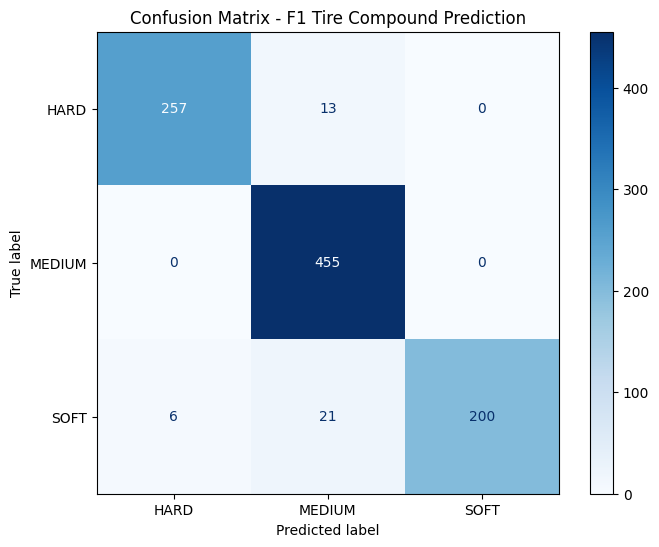

XGBOOST DECISION TREE


/home/c/Desktop/AI_MUAR/ai_f1/.venv/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


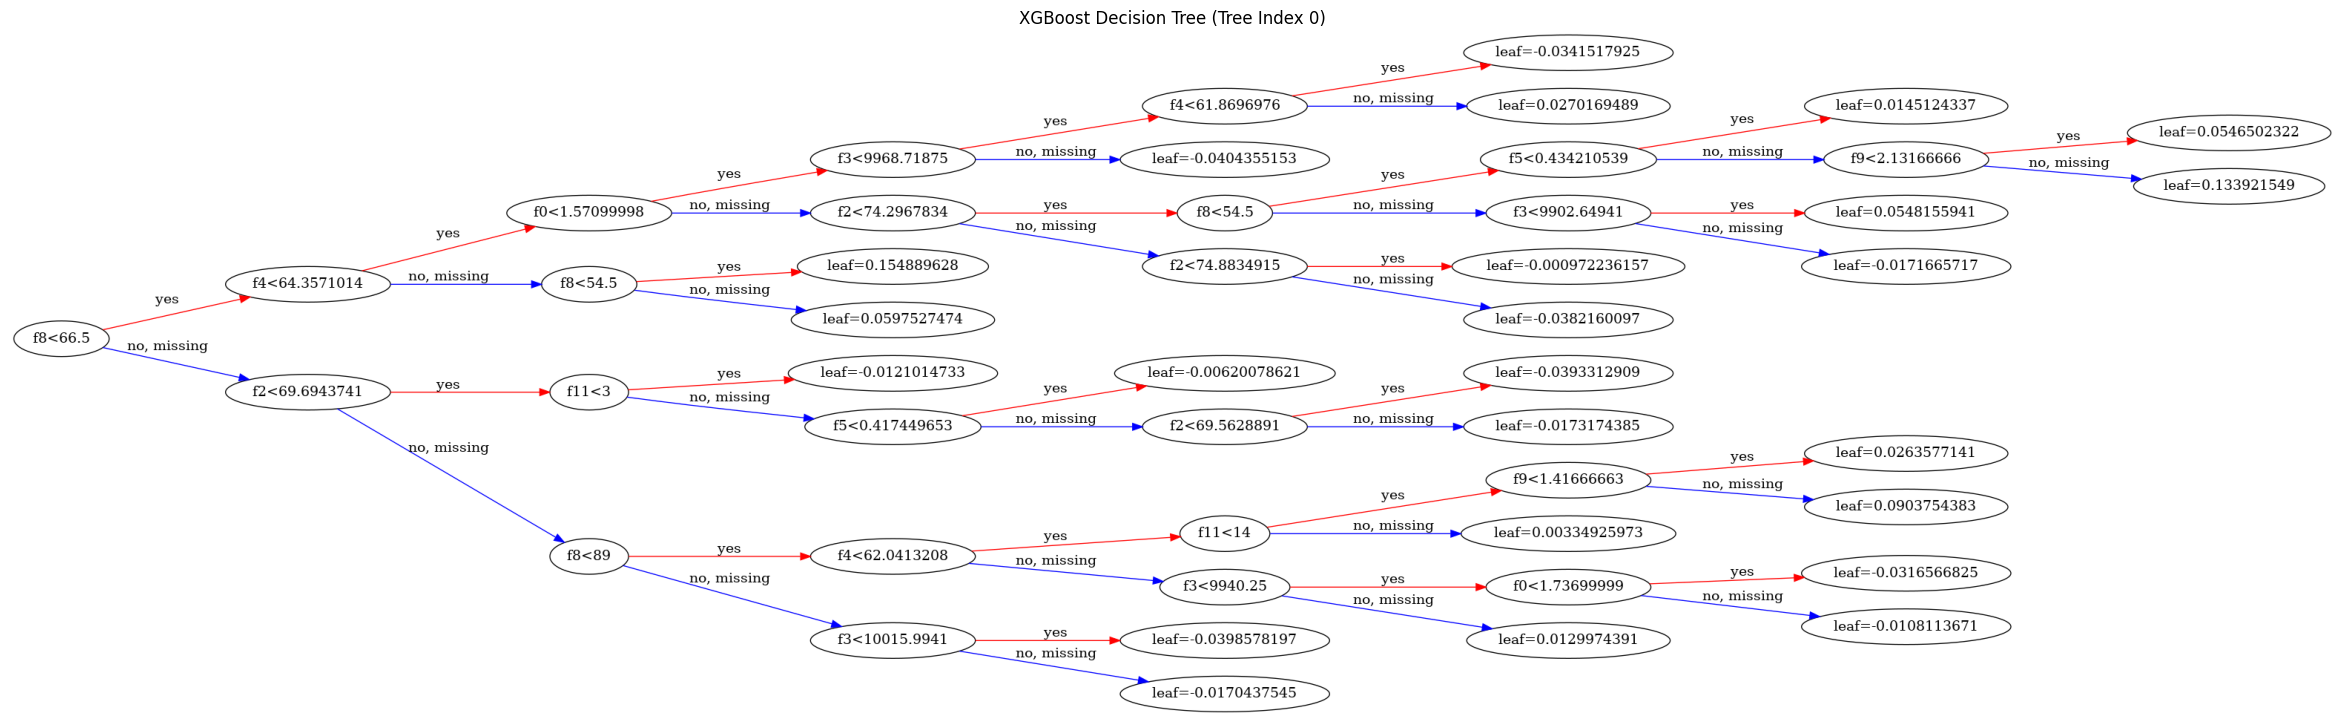

SHAP PLOT


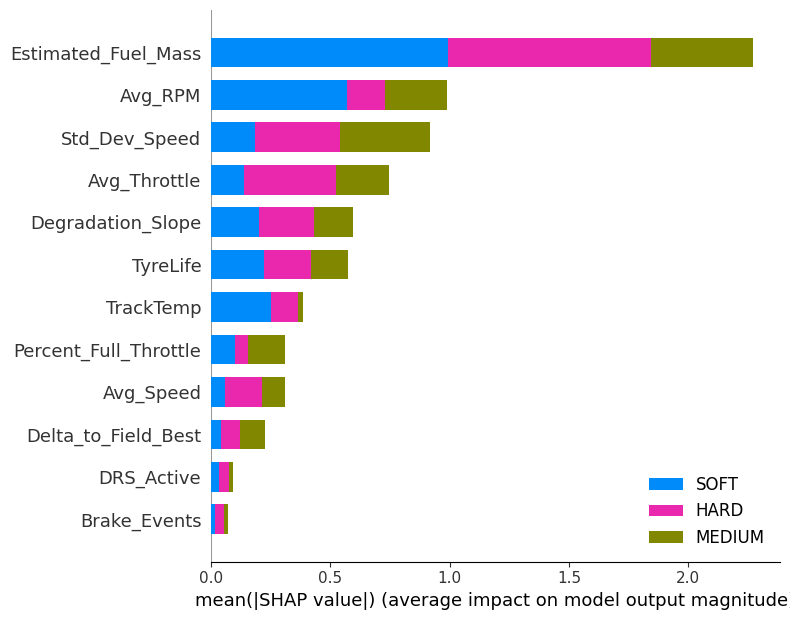

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap
import xgboost as xgb

##################################################################### EVALUATION ##############################################################

y_pred = final_model.predict(X)

target_names = ['HARD', 'MEDIUM', 'SOFT']
print(classification_report(y, y_pred, target_names=target_names))

# CONFUSION MATRIX
print("CONFUSION MATRIX")
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix - F1 Tire Compound Prediction")
plt.show()


# XGBoost Tree Visualization
print("XGBOOST DECISION TREE")
fig, ax = plt.subplots(figsize=(30, 15)) 
xgb.plot_tree(final_model, num_trees=0, ax=ax, rankdir='LR')
plt.title("XGBoost Decision Tree (Tree Index 0)")
plt.show()


# SHAP Interpretability Plot
print("SHAP PLOT")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X, class_names=target_names, plot_type="bar", show=True)
plt.show()

TRAININING on 775 laps. TESTING on 177 unseen laps.

 TRUE UNSEEN CLASSIFICATION REPORT
              precision    recall  f1-score   support

        HARD       0.38      0.28      0.32        36
      MEDIUM       0.21      0.42      0.28        38
        SOFT       0.71      0.51      0.60       103

    accuracy                           0.45       177
   macro avg       0.43      0.40      0.40       177
weighted avg       0.53      0.45      0.47       177


 CONFUSION MATRIX


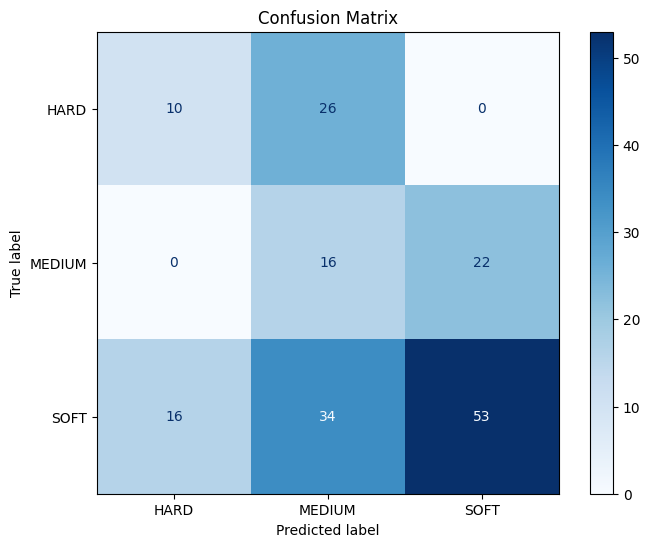


 XGBOOST DECISION TREE


/home/c/Desktop/AI_MUAR/ai_f1/.venv/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


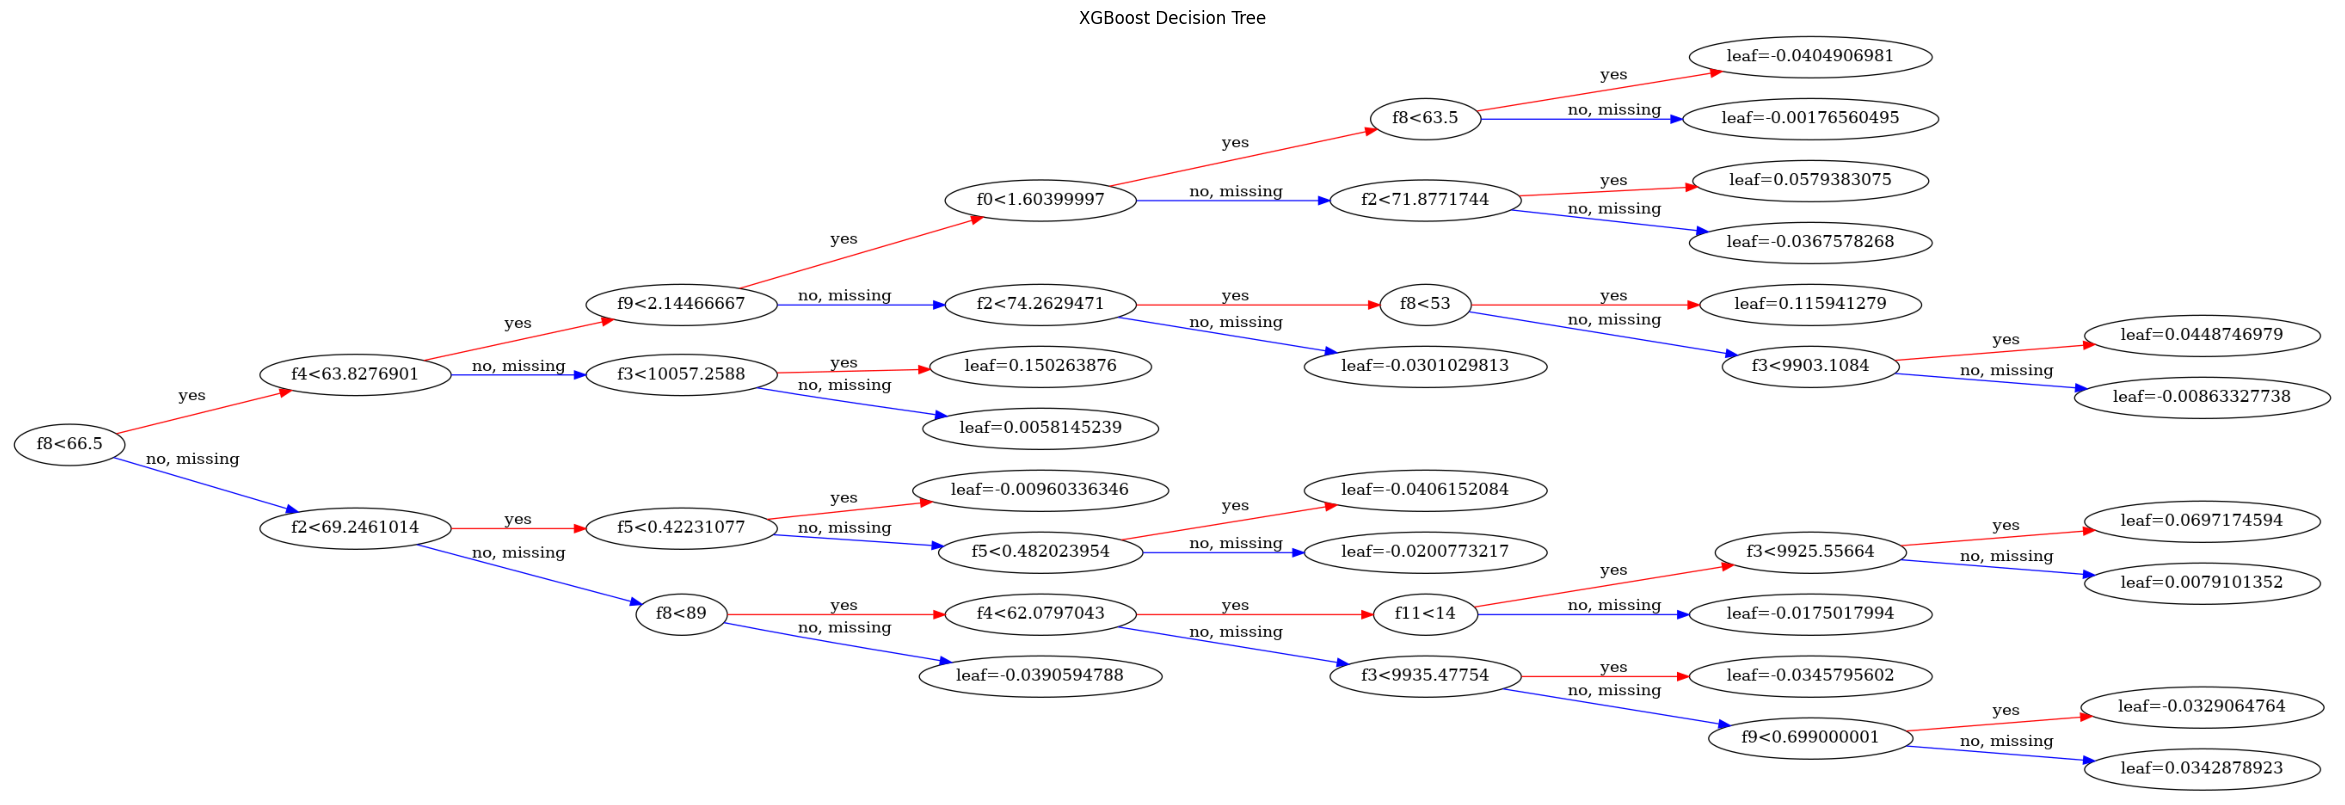


 SHAP INTERPRETABILITY


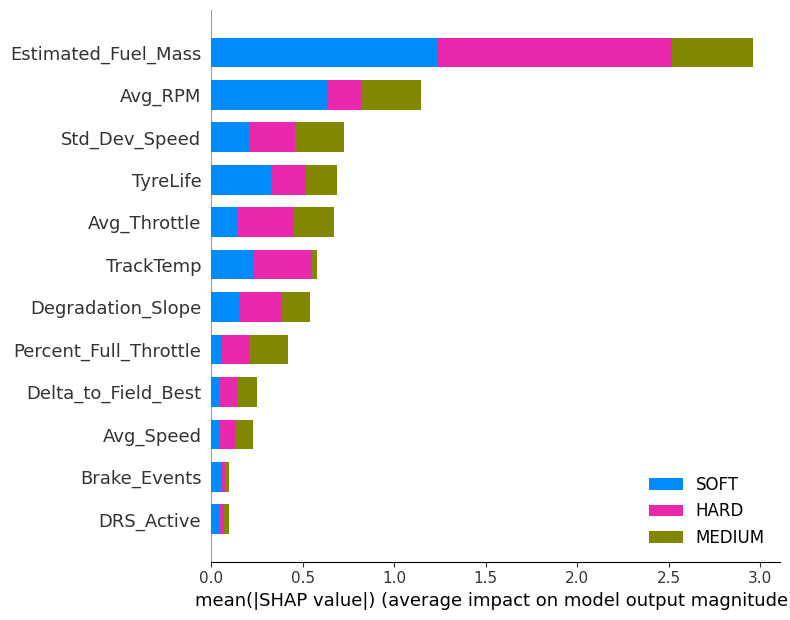

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

##################################################################### STRICT 80/20 HOLDOUT EVALUATION ##################################################

# set up grouped split - 80% Train, 20% Test
gss = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_strict = X.iloc[train_idx]
X_test_strict = X.iloc[test_idx]
y_train_strict = y.iloc[train_idx]
y_test_strict = y.iloc[test_idx]

print(f"TRAININING on {len(X_train_strict)} laps. TESTING on {len(X_test_strict)} unseen laps.")

# calc sample weights ONLY on training data
# train_sample_weights = compute_sample_weight(class_weight=custom_weights, y=y_train_strict)
train_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_strict)

# initialize and train the model ONLY on the 80% training data
strict_model = xgb.XGBClassifier(**best_params)
strict_model.fit(X_train_strict, y_train_strict, sample_weight=train_sample_weights)

# predict ONLY on the 20% holdout test data
y_pred_strict = strict_model.predict(X_test_strict)

print("\n TRUE UNSEEN CLASSIFICATION REPORT")
print(classification_report(y_test_strict, y_pred_strict, target_names=target_names))

print("\n CONFUSION MATRIX")
cm_strict = confusion_matrix(y_test_strict, y_pred_strict)
disp_strict = ConfusionMatrixDisplay(confusion_matrix=cm_strict, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp_strict.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix")
plt.show()

print("\n XGBOOST DECISION TREE")
fig, ax = plt.subplots(figsize=(30, 15)) 
xgb.plot_tree(strict_model, num_trees=0, ax=ax, rankdir='LR')
plt.title("XGBoost Decision Tree")
plt.show()

print("\n SHAP INTERPRETABILITY")
explainer_strict = shap.TreeExplainer(strict_model)
shap_values_strict = explainer_strict.shap_values(X_test_strict)

shap.summary_plot(shap_values_strict, X_test_strict, class_names=target_names, plot_type="bar", show=True)